# Generating quantum resource estimates (QREs) for the baseline circuit


### Brief background
In this work, we compile a 2D Fermi-Hubbard ground-state energy estimation algorithm for an active-volume architecture. We combine several compilation techniques to reduce the circuit’s total active volume. These techniques are described throughout the paper, and the resulting circuit is referred to as the "improved" circuit. The "baseline" circuit that we compare against is based on previous state of the art circuits described in [Campbell](https://arxiv.org/abs/2012.09238) and [Kan et al.](https://arxiv.org/abs/2411.02160), in which both works compiled the circuits with the goal of reducing the non-Clifford cost.

We outline how the baseline and improved circuits differ:

<img src="figures/baseline_vs_improved.png" width="700" alt="Baseline vs improved">

In this notebook, we instantiate the baseline circuits for even lattice sizes from 4 to 20 and and use Workbench’s resource-estimation tool to collect circuit metrics. These metrics include counts of non-Clifford operations, such as T and Toffoli gates, as well as estimates of the total active volume.

While the baseline circuits are based on [Kan et al.](https://arxiv.org/abs/2411.02160), we note the following:
1. The authors consider integer query counts that are not of the form $6 \times 2^l$ where $l$ is an integer. To align with the [original "entanglement-free" QPE work](https://arxiv.org/abs/0709.2996), we re-ran the error budget optimization while restricting the query count to this form. Because the corresponding control structure was not specified, we instantiate an uncontrolled query and multiply its cost by the total query count. This gives the baseline circuit a slight advantage over the improved circuit, for which the control structure is explicitly included.
2. For the baseline circuit, we apply Hamming weight phasing to all parallel equiangular rotations as a single batch, rather than dividing them into multiple batches.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import json
import warnings
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
import re

from psiq_fh.wb_program import FermiHubbardQreRunner
from psiq_fh.wb_program.utils import extract_all, json_dump, compute_T_rotation_synthesis_mixed_fallback

from process_callgraph_data import *


warnings.filterwarnings("ignore")

plt.rcParams.update(
    {
        "font.family": "serif",
        "font.serif": ["Times New Roman"],
        "mathtext.fontset": "stix",  # math font similar to Times
        "axes.labelsize": 22,
        "axes.titlesize": 22,
        "xtick.labelsize": 18,
        "ytick.labelsize": 18,
        "legend.fontsize": 15,
        "legend.title_fontsize": 24,
    }
)


# QRE setup
lattice_sizes = [4, 6, 8, 10, 12, 14, 16, 18, 20]
n_hwp_batches = 1

# Where we save QRE data
metrics_dir = Path(f"./paper_data_and_plots/baseline_metrics_data/{n_hwp_batches}batches/")
callgraph_dir = Path(f"./paper_data_and_plots/baseline_callgraph_data/{n_hwp_batches}batches/")

### Data collection

We instantiate the circuits for the specified lattice sizes by creating an instance of a "QRE runner." Here, we can specify the variant of the circuit to "baseline" as well as set the number of Hamming weight phasing (HWP) batches. For details on how the circuits are implemented, refer to the `wb_program` directory.

Note: the cell below takes ~2 minutes to run on a Macbook Pro M4 32GB.

In [3]:
%%time

runner = FermiHubbardQreRunner(lattice_sizes=lattice_sizes, variant="baseline", num_batches=n_hwp_batches)
metrics_data = runner.retrieve(save_callgraphs=True)

# Save the metrics data
json_dump(metrics_data, "baseline_circuit_expanded_metrics", metrics_dir)

CPU times: user 1min 54s, sys: 2.35 s, total: 1min 56s
Wall time: 1min 58s


In [4]:
# Extract particular metrics
cat_rotations = extract_all(metrics_data, "n_catalyst_rots")  # number of catalyst rotations
t_gates_wb = extract_all(metrics_data, "t_gates")  # number of T-gates
toffs_wb = extract_all(metrics_data, "aggregated_toff_count")  # number of Toffoli gates
qbits = extract_all(metrics_data, "qubit_highwater")  # number of logical qubits

### Cross-verification against Kan et al. Toffoli expression

As a sanity check, we can compare against the Toffoli count expression from Kan et al. To do so, we want to consolidate the non-Clifford cost coming from Toffoli gates and T-gates. Average costs for rotations have been added to the T-gate count. For the purpose of comparing against existing works, we assume all T states are catalyzed using CCZ states.

In [5]:
# To consolidate non-Clifford cost from T-gates and Toffoli gates
T_TO_TOFF = 2  # Assume all T states are catalyzed using CCZ states
toffs_from_t_gates_wb = t_gates_wb / T_TO_TOFF
total_toff_counts_wb = toffs_wb + toffs_from_t_gates_wb

In [6]:
# Load circuit parameters
eps_cats = np.zeros(len(lattice_sizes))  # precision of catalyst rotations
eps_noncats = np.zeros(len(lattice_sizes))  # precision of non-catalyst rotations
trotter_steps = np.zeros(len(lattice_sizes))  # number of Trotter steps
queries = np.zeros(len(lattice_sizes))  # number of queries

for i, x_dim in enumerate(lattice_sizes):
    lattice_size_x = x_dim
    lattice_size_y = lattice_size_x
    circuit_data = runner.load_circuit_data(x_dim, x_dim, raw=True)

    eps_cats[i] = 2**-circuit_data.cat_bop
    eps_noncats[i] = 2**-circuit_data.rot_bop

    trotter_steps[i] = circuit_data["no_trotter_steps"]
    queries[i] = circuit_data["no_queries"]

Below is a code implementation of the analytic Toffoli count expressions from Kan et al.

In [7]:
# Toffolis from catalyzed HWPs. See Eq (71) in arxiv:2411.02160v2.
lattice_sizes = np.asarray(lattice_sizes)
w_sq = np.array([int(L**2).bit_count() for L in lattice_sizes])
n_toff = (4 * trotter_steps + 1) * (lattice_sizes**2 + (np.floor(np.log2(lattice_sizes**2))).astype(int) - w_sq + 1)

# Catalyst RZ rotations. See Eq (73) in arxiv:2411.02160v2.
# Note: corrected number of catalysts in IPG
n_cats = 2 * (np.floor(np.log2(lattice_sizes**2))).astype(int) + 4
n_T1 = n_cats * compute_T_rotation_synthesis_mixed_fallback(eps_cats)

# Non-catalyst RZ rotations. See Eq (74) in arxiv:2411.02160v2.
n_noncats = 4 * trotter_steps + 1
n_T2 = n_noncats * compute_T_rotation_synthesis_mixed_fallback(eps_noncats)

# Total T counts. See Eq (75) in arxiv:2411.02160v2.
n_T_from_chads = 12 * trotter_steps * lattice_sizes**2  # in two-mode FFFTs
n_T = n_T_from_chads + n_T2  # these will be multiplied by the number of queries

# Total Toff cost (from T's and rotations as well)
toff_total_kan_et_al = n_toff * queries
toff_total_kan_et_al += (n_T * queries) / T_TO_TOFF  # 1 CCZ state -> 2 T states
toff_total_kan_et_al += n_T1 / T_TO_TOFF  # add catalyst cost

# Compare against Toffoli counts from Workbench circuits!
print(abs(toff_total_kan_et_al - total_toff_counts_wb))

[0.00000000e+00 1.16415322e-10 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00]


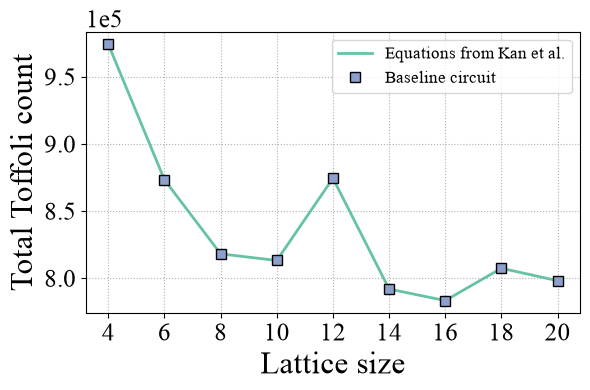

In [8]:
cmap = plt.get_cmap("Set2")

plt.figure(figsize=(6, 4))
plt.plot(lattice_sizes, toff_total_kan_et_al, color=cmap(0), lw=2, label="Equations from Kan et al.")
plt.plot(
    lattice_sizes, total_toff_counts_wb, "s", color=cmap(2), markersize=7, markeredgecolor="k", label="Baseline circuit"
)
plt.legend(fontsize=12)
plt.ylabel("Total Toffoli count")
plt.xlabel("Lattice size")
plt.grid(linestyle=":")
plt.xticks(lattice_sizes)
plt.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
plt.tight_layout()

We see a nice agreement between our Workbench circuit counts and those computed from the equations from Kan et al., providing additional confidence in our circuit implementation.

In [9]:
# Save total/consolidated Toffoli counts
baseline_toff_data = {}
for l, t in zip(lattice_sizes, total_toff_counts_wb):
    baseline_toff_data[int(l)] = float(t)
json_dump(baseline_toff_data, "baseline_toffs_total", metrics_dir)


# Save total/consolidated Toffoli counts from Kan et al.
kan_toff_data = {}
for l, t in zip(lattice_sizes, toff_total_kan_et_al):
    kan_toff_data[int(l)] = float(t)
json_dump(kan_toff_data, "kan_toffs_total", metrics_dir)

### Active volume estimation

We now extract the total active volume estimated using Workbench. The active volume is currently divided into three main categories or buckets: Clifford operations, non-Clifford operations, and black-box operations. For subroutines that have not been explicitly instantiated at the gate level, we can define black-box qubricks and assign them their expected costs, such as the number of T-gates, Toffoli gates, or active-volume blocks.

In [10]:
active_volume_wb_total = extract_all(metrics_data, "total_av")  # total active volume

cliff_av_wb_total = extract_all(metrics_data, "aggregated_clifford_av")  # active volume from Clifford operations
noncliff_av_wb_total = extract_all(
    metrics_data, "aggregated_non_clifford_av"
)  # active volume from non-Clifford operations
blackbox_rot_av_wb_total = extract_all(metrics_data, "black_box_av")  # active volume from black-box operations

# Sanity check: total active volume should be sum of clifford, non-clifford, and blackbox active volumes
assert np.allclose(active_volume_wb_total, cliff_av_wb_total + noncliff_av_wb_total + blackbox_rot_av_wb_total)

In the cell below, we compute and save the circuit volume, which is defined as the number of T-gates times the number of logical memory qubits.

In [11]:
# Compute circuit volume
total_t_counts_wb = t_gates_wb + T_TO_TOFF * toffs_wb

circuit_volume = total_t_counts_wb * qbits

# Save active volume and circuit volume
json_dump(active_volume_wb_total.tolist(), "baseline_av_total", metrics_dir)
json_dump(circuit_volume.tolist(), "baseline_cv_total", metrics_dir)

### Breakdown of active volume from Clifford and non-Clifford operations

Since we have a breakdown of the total active volume by Clifford and non-Clifford operations, we can plot these components to help see the dominant source of active volume. Note that in the baseline circuit, the blackbox qubrick functionality is used to estimate rotation synthesis costs, which we include as non-Clifford active volume.

In [12]:
# Percentage of active volume from Clifford and non-Clifford operations
pc_av_cliff_list = cliff_av_wb_total / active_volume_wb_total * 100
pc_av_noncliff_list = (noncliff_av_wb_total + blackbox_rot_av_wb_total) / active_volume_wb_total * 100

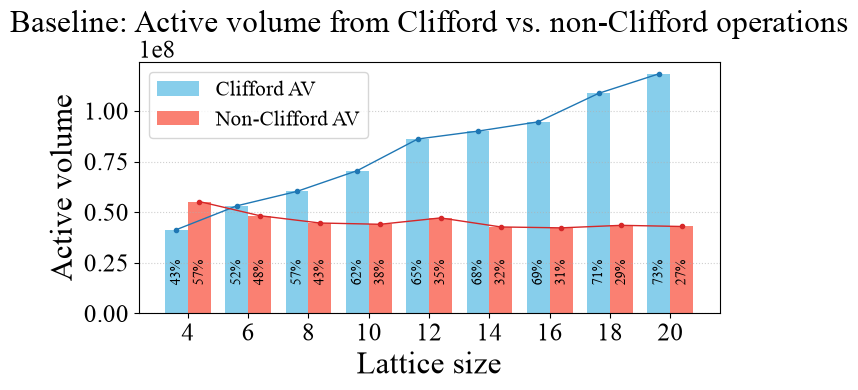

In [13]:
x = np.arange(len(lattice_sizes))
bar_width = 0.38

fig, ax = plt.subplots(figsize=(7, 4))

bars1 = ax.bar(x - bar_width / 2, cliff_av_wb_total, width=bar_width, label="Clifford AV", color="skyblue")
bars2 = ax.bar(
    x + bar_width / 2,
    noncliff_av_wb_total + blackbox_rot_av_wb_total,
    width=bar_width,
    label="Non-Clifford AV",
    color="salmon",
)

# Add text labels above the bars
label_y = 0.10 * max(np.max(cliff_av_wb_total), np.max(noncliff_av_wb_total))

# Connect the tops of the bars
ax.plot(x - bar_width / 2, cliff_av_wb_total, color="tab:blue", marker=".", linewidth=1, zorder=3)
ax.plot(
    x + bar_width / 2,
    noncliff_av_wb_total + blackbox_rot_av_wb_total,
    color="tab:red",
    marker=".",
    linewidth=1,
    zorder=3,
)

for i, bar in enumerate(bars1):
    height = bar.get_height()
    ax.annotate(
        f"{pc_av_cliff_list[i]:.0f}%",
        xy=(bar.get_x() + bar.get_width() / 2, label_y),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
    )


for i, bar in enumerate(bars2):
    height = bar.get_height()
    ax.annotate(
        f"{pc_av_noncliff_list[i]:.0f}%",
        xy=(bar.get_x() + bar.get_width() / 2, label_y),
        xytext=(0, 3),
        textcoords="offset points",
        ha="center",
        va="bottom",
        rotation=90,
    )

ax.set_xlabel("Lattice size")
ax.set_ylabel("Active volume")
ax.set_title("Baseline: Active volume from Clifford vs. non-Clifford operations")
ax.set_xticks(x)
ax.set_xticklabels(lattice_sizes)
ax.ticklabel_format(axis="y", style="sci", scilimits=(0, 0))
ax.grid(axis="y", alpha=0.6, linestyle=":")
ax.legend()
fig.tight_layout()

In [14]:
# Save active volume breakdown data
json_dump(cliff_av_wb_total.tolist(), "cliff_av", metrics_dir)
json_dump(pc_av_cliff_list.tolist(), "pc_av_cliff_list", metrics_dir)
json_dump((noncliff_av_wb_total + blackbox_rot_av_wb_total).tolist(), "noncliff_av", metrics_dir)
json_dump(pc_av_noncliff_list.tolist(), "pc_av_noncliff_list", metrics_dir)

### Active volume breakdown by subroutine

We can look into a more fine-grained breakdown of the total active volume using Construct's tool for generating callgraphs. We use a helper function to parse through this callgraph data structure.

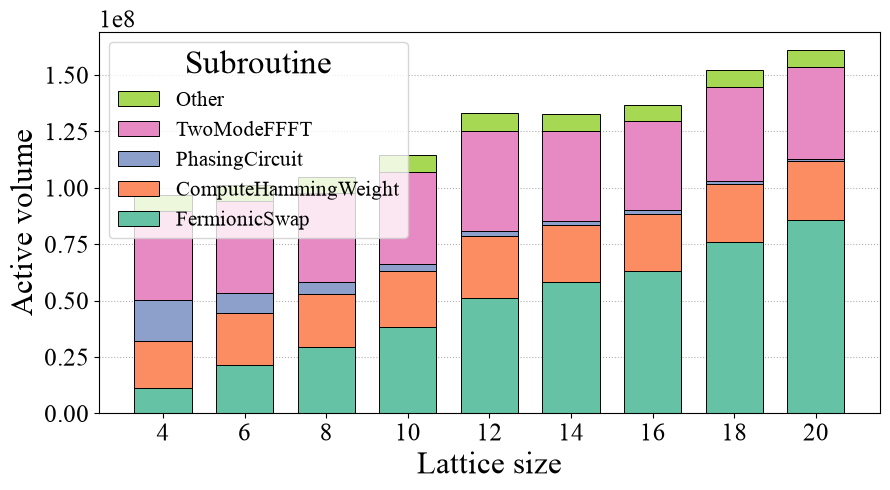

In [15]:
from process_callgraph_data import QreAnalysis

# Get list of callgraph data files sorted by lattice size
files = sorted(
    (f for f in callgraph_dir.iterdir() if f.is_file()), key=lambda f: int(re.search(r"(\d+)dim", f.name).group(1))
)
filepaths = [str(f) for f in files]

# Add data to a list
graph_list = [QreAnalysis.from_json(fpath) for fpath in filepaths]

# Major subroutines we want to track in the breakdown plot
groups = OrderedDict(
    [
        ("FermionicSwap", ("FermionicSwap",)),
        ("ComputeHammingWeight", ("ComputeHammingWeight",)),
        ("PhasingCircuit", ("PhasingCircuit",)),
        ("TwoModeFFFT", ("TwoModeFFFT",)),
    ]
)

ax = plot_av_breakdown_over_lattice_sizes(graph_list, lattice_sizes, title=None, groups=groups, figsize=(9, 5))

We have finished generating all the QRE data for the baseline circuit. To generate the QRE data for the improved circuit, see `generate_improved_data.ipynb`.